# mRNN Training From Combined Fixation PSTH

This notebook loads the stored `[-500 ms, +500 ms]` mean firing-rate export, reshapes it into the legacy three-condition format used by the modeling code, and trains a multi-regional RNN on those traces.

Assumptions used here:
- `high_interactivity_face`: split export, `face`, `interactive`
- `low_interactivity_face`: split export, `face`, `non_interactive`
- `object`: unsplit export, `object`
- modeled regions use the analysis names directly: `ofc`, `bla`, `dmpfc`, `accg`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find the repo root from the current working directory.")


repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

modeling_root = repo_root / "modeling"
if str(modeling_root) not in sys.path:
    sys.path.insert(0, str(modeling_root))

from dal_monte_2022_analysis.ephys.modeling import (
    MRNN_CONDITION_COLUMN_ORDER,
    MRNN_REGION_ORDER,
    build_mrnn_training_dataframe,
    load_combined_fixation_psth,
)

plt.rcParams["figure.dpi"] = 120
repo_root

PosixPath('/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis')

In [2]:
DATASET_CFG_PATH = "configs/dataset.yaml"
MRNN_CONFIG_PATH = repo_root / "modeling" / "configurations" / "mRNN.json"

loaded = load_combined_fixation_psth(DATASET_CFG_PATH)
combined_df = loaded.dataframe
timeline_s_rel = loaded.timeline_s_rel

print(f"Dataframe path: {loaded.dataframe_path}")
print(f"Timeline path: {loaded.timeline_path}")
print(f"Combined dataframe shape: {combined_df.shape}")
combined_df.head()

Dataframe path: /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_psth_averages/fixations_psth_10ms_combined_window_neg500ms_to_pos500ms.pkl
Timeline path: /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_psth_averages/fixations_psth_10ms_bin_centers_s_rel_window_neg500ms_to_pos500ms.pkl
Combined dataframe shape: (7206, 13)


,date,unit_uuid,region,spike_channel,recorded_agent,fixation_category,interactive_state,is_interactive,n_trials,psth_mean,psth_sem,source_fixation_monkeys,average_partition
0,01022019,unit_uuid__1200,ofc,SPK17,m1,face,interactive,True,1972,"[5.364809182542076, 5.362650038094984, 5.42429...","[0.316716830581736, 0.3214826141513702, 0.3251...","(Cronenberg, Lynch)",split
1,01022019,unit_uuid__1200,ofc,SPK17,m1,face,non_interactive,False,456,"[5.142777506345953, 5.060606394450068, 5.11514...","[0.570000411465561, 0.5625671549766208, 0.5742...","(Cronenberg, Lynch)",split
2,01022019,unit_uuid__1200,ofc,SPK17,m1,object,interactive,True,80,"[5.474674784825047, 5.474542436076626, 5.25161...","[1.6833719467895722, 1.7371328195031825, 1.708...","(Lynch,)",split
3,01022019,unit_uuid__1200,ofc,SPK17,m1,object,non_interactive,False,42,"[6.367635613692364, 6.411706146156131, 6.14256...","[2.358255231124814, 2.3028330790754308, 2.2091...","(Lynch,)",split
4,01022019,unit_uuid__1201,ofc,SPK19,m1,face,interactive,True,1972,"[4.491765710666424, 4.4900678405860015, 4.4885...","[0.20293948253601155, 0.20368699717442706, 0.2...","(Cronenberg, Lynch)",split


In [3]:
condition_counts = (
    combined_df.groupby(
        ["average_partition", "fixation_category", "interactive_state"],
        dropna=False,
    )
    .size()
    .rename("n_rows")
    .reset_index()
)

summary = pd.DataFrame(
    {
        "n_rows": [len(combined_df)],
        "n_units": [combined_df["unit_uuid"].nunique()],
        "regions": [", ".join(sorted(combined_df["region"].dropna().astype(str).unique()))],
        "timeline_bins": [len(timeline_s_rel)],
        "timeline_start_ms": [timeline_s_rel[0] * 1000.0],
        "timeline_stop_ms": [timeline_s_rel[-1] * 1000.0],
    }
)

display(summary)
condition_counts

,n_rows,n_units,regions,timeline_bins,timeline_start_ms,timeline_stop_ms
0,7206,1201,"accg, bla, dmpfc, ofc",100,-495.0,495.0


,average_partition,fixation_category,interactive_state,n_rows
0,split,face,interactive,1201
1,split,face,non_interactive,1201
2,split,object,interactive,1201
3,split,object,non_interactive,1201
4,unsplit,face,NaN,1201
5,unsplit,object,NaN,1201


In [4]:
training_df = build_mrnn_training_dataframe(combined_df)
print(f"Training dataframe shape: {training_df.shape}")
display(training_df.head())

region_summary = (
    training_df.groupby("region", sort=False)
    .agg(
        n_units=("uuid", "nunique"),
        mean_hi_trials=("high_interactivity_face_n_trials", "mean"),
        mean_low_trials=("low_interactivity_face_n_trials", "mean"),
        mean_object_trials=("object_n_trials", "mean"),
    )
    .reset_index()
)
region_summary

Training dataframe shape: (1201, 12)


,date,uuid,region,source_region,spike_channel,recorded_agent,high_interactivity_face,low_interactivity_face,object,high_interactivity_face_n_trials,low_interactivity_face_n_trials,object_n_trials
0,01022019,unit_uuid__1200,ofc,ofc,SPK17,m1,"[5.364809182542076, 5.362650038094984, 5.42429...","[5.142777506345953, 5.060606394450068, 5.11514...","[5.782087529189205, 5.797172565776127, 5.55833...",1972,456,122
1,01022019,unit_uuid__1201,ofc,ofc,SPK19,m1,"[4.491765710666424, 4.4900678405860015, 4.4885...","[4.277015821029592, 4.311224642740954, 4.33060...","[5.45424130422629, 5.314965831190856, 5.171479...",1972,456,122
2,01022019,unit_uuid__1202,ofc,ofc,SPK20,m1,"[8.13396706757649, 8.196986203482735, 8.200910...","[8.289015726611039, 8.1921920347908, 8.1534109...","[9.837894945892701, 9.813715182637138, 9.80188...",1972,456,122
3,01022019,unit_uuid__1203,ofc,ofc,SPK25,m1,"[8.036550925444448, 8.126800995235454, 8.23125...","[7.190844038056618, 7.308786379136367, 7.50444...","[6.8359747003959885, 7.1950685187693875, 7.498...",1972,456,122
4,01022019,unit_uuid__1204,ofc,ofc,SPK26,m1,"[11.946032117708645, 11.862180160967007, 11.91...","[12.522904846081397, 12.457345195687852, 12.42...","[13.675949415598378, 13.094002437273899, 12.95...",1972,456,122


,region,n_units,mean_hi_trials,mean_low_trials,mean_object_trials
0,ofc,241,982.087137,190.597510,183.858921
1,bla,537,916.692737,167.078212,210.048417
2,dmpfc,187,953.791444,176.828877,196.775401
3,accg,236,896.334746,157.813559,208.402542


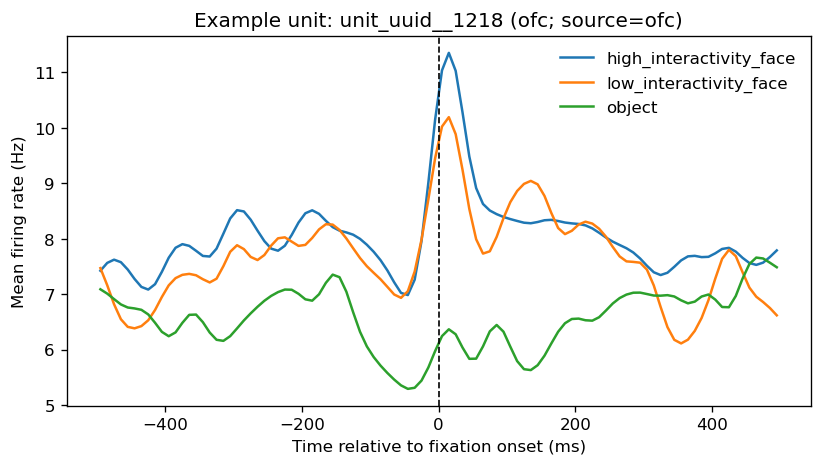

In [5]:
row = training_df.iloc[16]

fig, ax = plt.subplots(figsize=(8, 4))
for condition_name in MRNN_CONDITION_COLUMN_ORDER:
    ax.plot(
        timeline_s_rel * 1000.0,
        np.asarray(row[condition_name], dtype=float),
        label=condition_name,
    )
ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Time relative to fixation onset (ms)")
ax.set_ylabel("Mean firing rate (Hz)")
ax.set_title(
    f"Example unit: {row['uuid']} ({row['region']}; source={row['source_region']})"
)
ax.legend(frameon=False)
plt.show()

## Training

The next cells use the legacy modeling `Model` class directly. They require a notebook kernel with `torch` and `mrnntorch` installed.

This version trains on the raw per-unit traces. If you want to match the old latent-training flow exactly, add a per-region PCA projection step before calling the model.

In [6]:
import sys, subprocess, pkgutil, importlib.util

print(sys.executable)
subprocess.run([sys.executable, "-m", "pip", "show", "mrnntorch"])
print("mrnntorch:", importlib.util.find_spec("mrnntorch"))

subprocess.run([sys.executable, "-m", "pip", "show", "mRNNTorch"])
print("mRNNTorch.mRNN:", importlib.util.find_spec("mRNNTorch.mRNN"))


/gpfs/milgram/project/chang/pg496/conda_envs/gaze_processing/bin/python
Name: mrnntorch
Version: 0.1.0
Summary: 
Home-page: 
Author: 
Author-email: 
License: 
Location: /gpfs/milgram/project/chang/pg496/conda_envs/gaze_processing/lib/python3.11/site-packages
Editable project location: /gpfs/milgram/pi/chang/pg496/repositories/mRNNTorch
Requires: 
Required-by: 
mrnntorch: ModuleSpec(name='mrnntorch', loader=<_frozen_importlib_external.SourceFileLoader object at 0x154a62297810>, origin='/gpfs/milgram/pi/chang/pg496/repositories/mRNNTorch/src/mrnntorch/__init__.py', submodule_search_locations=['/gpfs/milgram/pi/chang/pg496/repositories/mRNNTorch/src/mrnntorch'])
Name: mrnntorch
Version: 0.1.0
Summary: 
Home-page: 
Author: 
Author-email: 
License: 
Location: /gpfs/milgram/project/chang/pg496/conda_envs/gaze_processing/lib/python3.11/site-packages
Editable project location: /gpfs/milgram/pi/chang/pg496/repositories/mRNNTorch
Requires: 
Required-by: 
mRNNTorch.mRNN: ModuleSpec(name='mRNNTorc

In [ ]:
import json

import torch
import torch.nn as nn
import torch.optim as optim

from modeling.utils.models import Model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

In [ ]:
def normalize_values(values: np.ndarray) -> np.ndarray:
    scale = np.percentile(values, 95) - np.percentile(values, 5)
    return values / (scale + 5.0)


def build_condition_batch(
    dataframe: pd.DataFrame,
    *,
    condition_columns=MRNN_CONDITION_COLUMN_ORDER,
    region_order=MRNN_REGION_ORDER,
    normalize: bool = True,
    batch_first: bool = True,
):
    ordered = dataframe.copy()
    ordered["region"] = pd.Categorical(
        ordered["region"], categories=region_order, ordered=True
    )
    ordered = ordered.sort_values(["region", "date", "uuid"]).reset_index(drop=True)

    observed_regions = ordered["region"].dropna().astype(str).unique().tolist()
    missing_regions = [region for region in region_order if region not in observed_regions]
    if missing_regions:
        raise ValueError(f"Missing modeled regions: {missing_regions}")

    region_unit_counts = {
        region: int((ordered["region"].astype(str) == region).sum())
        for region in region_order
    }

    condition_matrices = []
    for condition_name in condition_columns:
        traces = [
            np.asarray(trace, dtype=float).reshape(-1)
            for trace in ordered[condition_name].tolist()
        ]
        lengths = sorted({trace.shape[0] for trace in traces})
        if len(lengths) != 1:
            raise ValueError(
                f"Inconsistent trace lengths for {condition_name}: {lengths}"
            )
        matrix = np.column_stack(traces)
        if normalize:
            matrix = normalize_values(matrix)
        condition_matrices.append(torch.tensor(matrix, dtype=torch.float32))

    stack_dim = 0 if batch_first else 1
    batch = torch.stack(condition_matrices, dim=stack_dim)
    return batch, region_unit_counts, ordered


def build_condition_input(condition_names, timesteps, *, device):
    input_tensor = torch.zeros(
        (len(condition_names), timesteps, 3),
        dtype=torch.float32,
        device=device,
    )
    condition_index = {
        "high_interactivity_face": 0,
        "low_interactivity_face": 1,
        "object": 2,
    }
    for row_idx, condition_name in enumerate(condition_names):
        input_tensor[row_idx, :, condition_index[condition_name]] = 1.0
    return input_tensor


def l1_weight(rnn, scale):
    penalty = 0.0
    for _, param in rnn.named_parameters():
        penalty = penalty + torch.mean(torch.abs(torch.flatten(param)))
    return penalty * scale


def l1_rate(act, scale):
    return scale * torch.mean(torch.abs(torch.flatten(act)))


def get_loss_fn(loss_fn):
    if loss_fn == "mse":
        return nn.MSELoss()
    if loss_fn == "mae":
        return nn.L1Loss()
    if loss_fn == "smooth_l1":
        return nn.SmoothL1Loss()
    raise ValueError(f"Unsupported loss_fn {loss_fn!r}; use mse, mae, or smooth_l1.")


def make_initial_state(kind, shape, *, device, scale=0.01):
    if kind == "zeros":
        return torch.zeros(shape, device=device)
    if kind == "normal":
        return scale * torch.randn(shape, device=device)
    if kind == "uniform":
        return torch.empty(shape, device=device).uniform_(-scale, scale)
    raise ValueError(f"Unsupported initial_state {kind!r}; use zeros, normal, or uniform.")

In [ ]:
batch, region_unit_counts, ordered_training_df = build_condition_batch(training_df)
print(f"Batch shape: {tuple(batch.shape)}")
region_unit_counts

Batch shape: (3, 100, 1201)


{'ofc': 241, 'bla': 537, 'dmpfc': 187, 'accg': 236}

In [ ]:
def train_mrnn(
    batch,
    region_unit_counts,
    *,
    mrnn_config_path=MRNN_CONFIG_PATH,
    epochs: int = 500,
    hidden_size: int = 100,
    lr: float = 1e-3,
    loss_fn: str = "mse",
    initial_state: str = "zeros",
    initial_state_scale: float = 0.01,
    dt: int = 10,
    tau: int = 100,
    l1_weight_scale: float = 1e-4,
    l1_rate_scale: float = 1e-4,
    inp_noise: float = 0.0,
    act_noise: float = 0.0,
    rec_constrained: bool = False,
    inp_constrained: bool = False,
    batch_first: bool = True,
    spectral_radius: float = 1.3,
    output_layer: bool = True,
    latent_training: bool = False,
    n_components: int = 10,
    model_save_name: str = "social_mrnn_from_combined_psth_raw",
    save_dir=None,
):
    if latent_training:
        raise NotImplementedError(
            "This notebook currently trains directly on the per-unit traces. "
            "Add a per-region PCA projection first if you want latent training."
        )

    save_dir = (
        Path(save_dir)
        if save_dir is not None
        else repo_root / "modeling" / "checkpoints" / model_save_name
    )
    save_dir.mkdir(parents=True, exist_ok=True)

    model = Model(
        str(mrnn_config_path),
        hidden_size,
        region_unit_counts["dmpfc"],
        region_unit_counts["accg"],
        region_unit_counts["ofc"],
        region_unit_counts["bla"],
        dt,
        tau,
        inp_noise,
        act_noise,
        rec_constrained,
        inp_constrained,
        batch_first,
        spectral_radius,
        output_layer=output_layer,
        latent_training=latent_training,
        n_components=n_components,
        device=str(device),
    ).to(device)

    xn_0 = nn.Parameter(
        make_initial_state(
            initial_state,
            (1, model.mrnn.total_num_units),
            device=device,
            scale=initial_state_scale,
        )
    )

    optimizer = optim.Adam([*model.parameters(), xn_0], lr=lr)
    criterion = get_loss_fn(loss_fn)

    target = batch.to(device)
    loss_mask = torch.ones_like(target)
    inp = build_condition_input(
        MRNN_CONDITION_COLUMN_ORDER,
        target.shape[1],
        device=device,
    )

    hp = {
        "mrnn_config_file": str(mrnn_config_path),
        "epochs": epochs,
        "hidden_size": hidden_size,
        "lr": lr,
        "loss_fn": loss_fn,
        "initial_state": initial_state,
        "initial_state_scale": initial_state_scale,
        "dt": dt,
        "tau": tau,
        "l1_weight_scale": l1_weight_scale,
        "l1_rate_scale": l1_rate_scale,
        "inp_noise": inp_noise,
        "act_noise": act_noise,
        "rec_constrained": rec_constrained,
        "inp_constrained": inp_constrained,
        "batch_first": batch_first,
        "spectral_radius": spectral_radius,
        "output_layer": output_layer,
        "latent_training": latent_training,
        "n_components": n_components,
        "model_save_name": model_save_name,
        "region_unit_counts": region_unit_counts,
        "condition_columns": list(MRNN_CONDITION_COLUMN_ORDER),
    }

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        out, hn = model(xn_0, inp)
        out = out * loss_mask

        mse_loss = criterion(out, target)
        rate_loss = l1_rate(hn, l1_rate_scale)
        weight_loss = l1_weight(model.mrnn, l1_weight_scale)
        loss = mse_loss + rate_loss + weight_loss

        loss.backward()
        optimizer.step()

        record = {
            "epoch": epoch,
            "loss": float(loss.detach().cpu()),
            "mse_loss": float(mse_loss.detach().cpu()),
            "rate_loss": float(rate_loss.detach().cpu()),
            "weight_loss": float(weight_loss.detach().cpu()),
        }
        history.append(record)

        if epoch == 1 or epoch % 100 == 0:
            print(
                f"epoch={epoch:5d} "
                f"loss={record['loss']:.6f} "
                f"mse={record['mse_loss']:.6f} "
                f"rate={record['rate_loss']:.6f} "
                f"weight={record['weight_loss']:.6f}"
            )

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "xn_0": xn_0.detach().cpu(),
        "hn_0": model.mrnn.activation(xn_0.detach()).cpu(),
        "region_unit_counts": region_unit_counts,
        "condition_columns": list(MRNN_CONDITION_COLUMN_ORDER),
        "timeline_s_rel": timeline_s_rel,
    }
    torch.save(checkpoint, save_dir / f"{model_save_name}.pth")

    with (save_dir / "hp.json").open("w", encoding="utf-8") as f:
        json.dump(hp, f, indent=2)

    history_df = pd.DataFrame(history)
    history_df.to_json(save_dir / "history.json", orient="records", indent=2)
    return model, history_df, checkpoint, save_dir

In [ ]:
MODEL_SAVE_NAME = "social_mrnn_from_combined_psth_raw"
EPOCHS = 500

model, history_df, checkpoint, save_dir = train_mrnn(
    batch,
    region_unit_counts,
    epochs=EPOCHS,
    model_save_name=MODEL_SAVE_NAME,
)

print(f"Saved checkpoint directory: {save_dir}")
history_df.tail()

epoch=    1 loss=0.509525 mse=0.509317 rate=0.000084 weight=0.000124
epoch=  100 loss=0.002772 mse=0.002608 rate=0.000041 weight=0.000123
epoch=  200 loss=0.001993 mse=0.001829 rate=0.000042 weight=0.000122
epoch=  300 loss=0.001672 mse=0.001507 rate=0.000043 weight=0.000122
epoch=  400 loss=0.001448 mse=0.001282 rate=0.000044 weight=0.000123
epoch=  500 loss=0.001291 mse=0.001124 rate=0.000044 weight=0.000123
Saved checkpoint directory: /gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/modeling/checkpoints/social_mrnn_from_combined_psth_raw


,epoch,loss,mse_loss,rate_loss,weight_loss
495,496,0.001296,0.001129,0.000044,0.000123
496,497,0.001295,0.001128,0.000044,0.000123
497,498,0.001294,0.001127,0.000044,0.000123
498,499,0.001292,0.001125,0.000044,0.000123
499,500,0.001291,0.001124,0.000044,0.000123


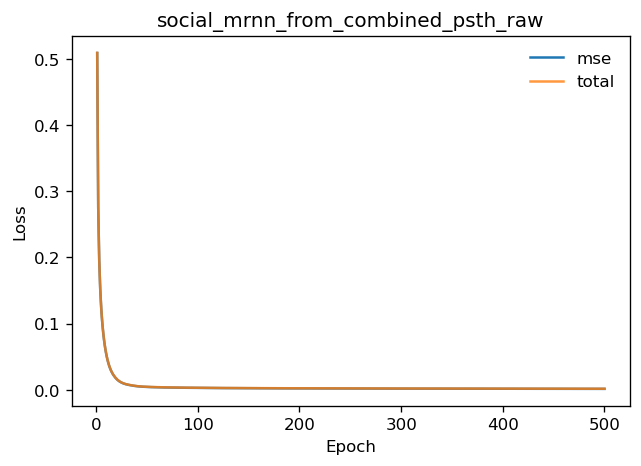

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_df["epoch"], history_df["mse_loss"], label="mse")
ax.plot(history_df["epoch"], history_df["loss"], label="total", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(MODEL_SAVE_NAME)
ax.legend(frameon=False)
plt.show()